## Differential Evolution

In this session, we will discover how Differential Evolution (DE) works. We will explore the underlying principles, implement core components from scratch, apply DE to classic benchmark functions, visualize its dynamics through a generated GIF, and tackle constraints.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.collections import PathCollection
from typing import Callable
from dataclasses import dataclass

### Optimization Problems

This cell defines three common benchmark functions, Sphere, Rosenbrock, and Rastrigin, used to test optimization algorithms. We also used these functions earlier to evaluate Adam, Momentum, and CMA-ES.

In [2]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1.0 - x[:-1]) ** 2.0))


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))

BOUNDS = [(-5, 5), (-5, 5)]

### Differential Evolution

Differential Evolution is a simple yet powerful **population-based search algorithm** for continuous optimization. At every iteration it maintains a population of $pop\_size$ candidate solutions, each an $n$-dimensional real-valued vector. Three straightforward operators: mutation, crossover, and selection, are applied to push the population toward regions of lower objective value.

#### 1. Initialisation  
Randomly sample $pop\_size$ vectors inside the problem's bounds.

#### 2. Mutation  
For each target vector $x_i$:

1. Select three distinct solutions $a$, $b$, $c$ (none equal to $x_i$) from current population.  
2. Create the mutant  
   $$v = a + F\,(b - c)$$
   where $F \in (0.4,1^+)$ is the scaling factor. The difference $(b-c)$ supplies direction and scale; $F$ stretches or shrinks the step.

#### 3. Crossover  
Blend the mutant $v$ with its target $x_i$ to form the trial vector \(u\):

- For each coordinate $j$, copy $v_j$ into $u_j$ with probability $CR$; otherwise copy $x_{i,j}$.  
- Force at least one coordinate to come from $v$ so that $u \neq x_i$.

Here $CR \in [0,1]$ is the *crossover rate*: higher $CR$ means aggressive mixing; lower $CR$ leaves the mutant mostly intact.

#### 4. Selection  
Evaluate the objective $f(\cdot)$: $u \text{ replaces } x_i \quad \text{if} \quad f(u) < f(x_i)$

Greedy replacement ensures the population does not deteriorate.

#### 5. Iteration & Termination  
After every target has produced a trial and selection is done, the new population is complete. Repeat until a generation limit, a fitness threshold, or a stall criterion is reached.

#### 6. Parameter intuition  

| Parameter | Typical range |
|-----------|---------------|
| Differential weight \(F\) | 0.4 – 1.0 |
| Crossover rate \(CR\)     | 0.1 – 0.9 |
| Population size \(P\)     | $5n$ – $10n$ |

In [3]:
from dataclasses import dataclass
from typing import Callable
import numpy as np


@dataclass
class DEResult:
    best_vector: np.ndarray
    best_value: float
    history: list[np.ndarray]  # History of populations for animation


def differential_evolution(
    func: Callable[[np.ndarray], float],
    bounds: list[tuple[float, float]] = BOUNDS,
    pop_size: int = 50,
    F: float = 0.8,
    CR: float = 0.9,
    max_gen: int = 100,
    seed: int | None = None,
) -> DEResult:
    """
    Implements the Differential Evolution algorithm for global optimization.

    Parameters:
        func: Objective function to minimize. Takes a numpy array and returns a float.
        bounds: list of (min, max) pairs for each dimension.
        pop_size: Number of individuals in the population.
        F: Mutation factor (typically in [0.4, 1.0]).
        CR: Crossover rate (typically in [0, 1]).
        max_gen: Maximum number of generations to evolve.
        seed: Optional RNG seed for reproducible runs.
    """
    np.random.seed(seed)

    dimensions = len(bounds)
    lower_bounds = np.array([b[0] for b in bounds])
    upper_bounds = np.array([b[1] for b in bounds])

    # --- TODO: Exercise 1 - Initialization ---
    population = np.random.uniform(
        low=lower_bounds,
        high=upper_bounds,
        size=(pop_size, dimensions)
    )

    fitness = np.array([func(individual) for individual in population])
    history = [population.copy()]
    # --- End Exercise 1 ---

    for generation in range(max_gen):
        new_population = population.copy()
        new_fitness = fitness.copy()

        for i in range(pop_size):
            target_vector = population[i]

            # --- TODO: Exercise 2 - Mutation ---
            candidate_indices = [idx for idx in range(pop_size) if idx != i]
            a_idx, b_idx, c_idx = np.random.choice(
                candidate_indices,
                size=3,
                replace=False
            )

            a = population[a_idx]
            b = population[b_idx]
            c = population[c_idx]

            mutant_vector = a + F * (b - c)
            mutant_vector = np.clip(mutant_vector, lower_bounds, upper_bounds)
            # --- End Exercise 2 ---

            # --- TODO: Exercise 3 - Crossover ---
            trial_vector = target_vector.copy()
            j_rand = np.random.randint(dimensions)

            for j in range(dimensions):
                r = np.random.rand()

                if r < CR or j == j_rand:
                    trial_vector[j] = mutant_vector[j]
                else:
                    trial_vector[j] = target_vector[j]
            # --- End Exercise 3 ---

            # --- TODO: Exercise 4 - Selection ---
            trial_fitness = func(trial_vector)

            if trial_fitness <= fitness[i]:
                new_population[i] = trial_vector
                new_fitness[i] = trial_fitness
            else:
                new_population[i] = target_vector
                new_fitness[i] = fitness[i]
            # --- End Exercise 4 ---

        population = new_population
        fitness = new_fitness
        history.append(population.copy())

    best_idx = np.argmin(fitness)

    return DEResult(
        best_vector=population[best_idx],
        best_value=fitness[best_idx],
        history=history
    )

### Test implemented DE

In [4]:
result = differential_evolution(sphere, bounds=BOUNDS, pop_size=50)

### Visualizing Search Dynamics

In [5]:
def animate_de(
    func: Callable[[np.ndarray], float],
    history: list[np.ndarray],
    bounds: list[tuple[float, float]] = BOUNDS,
    frames: int | None = None,
    filename: str = "de_animation.gif",
) -> None:
    """
    Creates and saves a GIF showing how the DE population moves over generations.
    """
    if frames is None:
        frames = len(history)

    assert len(bounds) == 2, "This function only supports 2D visualization (expected 2 bounds)."
    x_bounds = (bounds[0][0], bounds[0][1])
    y_bounds = (bounds[1][0], bounds[1][1])

    x = np.linspace(x_bounds[0], x_bounds[1], 200)
    y = np.linspace(y_bounds[0], y_bounds[1], 200)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(X, Y, Z, levels=20, cmap="viridis")
    fig.colorbar(contour, ax=ax)

    # Track only the scatters we add so we can remove them between frames
    # without touching the contour (works across matplotlib versions).
    scatters: list = []

    def update(i: int):
        while scatters:
            scatters.pop().remove()

        ax.set_title(f"Generation {i}")

        DECAY_CONSTANT = 10

        # Plot all generations up to i, with alpha decreasing for older points
        for j in range(i + 1):
            age = i - j
            alpha = float(np.exp(-age / DECAY_CONSTANT))
            pop_j = history[j]
            scatters.append(
                ax.scatter(pop_j[:, 0], pop_j[:, 1], s=24, color="red", edgecolors="none", alpha=alpha)
            )

        # Return an empty tuple since we're redrawing everything
        return ()

    ax.set_xlim(x_bounds[0], x_bounds[1])
    ax.set_ylim(y_bounds[0], y_bounds[1])

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=200,
        blit=False,  # must be False since we redraw each frame
    )

    writer = animation.PillowWriter(fps=5)
    anim.save(filename, writer=writer)
    plt.close(fig)
    print(f"Animation saved to {filename}")

In [6]:
animate_de(func=sphere, history=result.history)

Animation saved to de_animation.gif


### Experiments
Run DE on all three problems: Sphere, Rosenbrock and Rastrigin. For each problem:
- Generate and analyze convergence plots showing the progression of the best fitness value over iterations.
- Visualize the population dynamics over time to illustrate how the search space is explored and exploited.

In [7]:
def get_best_fitness_history(
    func: Callable[[np.ndarray], float],
    history: list[np.ndarray],
) -> np.ndarray:
    """
    Computes the best fitness value in each generation.
    """
    best_values = []

    for population in history:
        fitness_values = np.array([func(individual) for individual in population])
        best_values.append(np.min(fitness_values))

    return np.array(best_values)

In [8]:
def plot_convergence(
    func: Callable[[np.ndarray], float],
    history: list[np.ndarray],
    title: str,
) -> None:
    """
    Plots the best fitness value over generations.
    """
    best_values = get_best_fitness_history(func, history)

    plt.figure(figsize=(8, 5))
    plt.plot(best_values)
    plt.yscale("log")
    plt.xlabel("Generation")
    plt.ylabel("Best fitness value")
    plt.title(title)
    plt.grid(True)
    plt.show()

In [9]:
experiments = {
    "Sphere": sphere,
    "Rosenbrock": rosenbrock,
    "Rastrigin": rastrigin,
}

results = {}

for name, func in experiments.items():
    result = differential_evolution(
        func=func,
        bounds=BOUNDS,
        pop_size=50,
        F=0.8,
        CR=0.9,
        max_gen=100,
        seed=42,
    )

    results[name] = result

    print(f"{name}")
    print(f"Best vector: {result.best_vector}")
    print(f"Best value:  {result.best_value}")
    print()

Sphere
Best vector: [ 2.95506543e-09 -2.31079799e-09]
Best value:  1.4072199022248725e-17

Rosenbrock
Best vector: [0.99999782 0.99999597]
Best value:  1.5963298462457038e-11

Rastrigin
Best vector: [ 2.57312089e-05 -1.46823434e-05]
Best value:  1.7412205366440503e-07



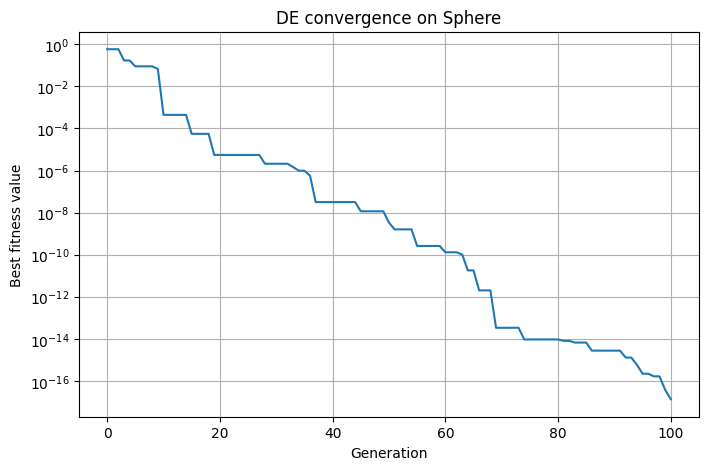

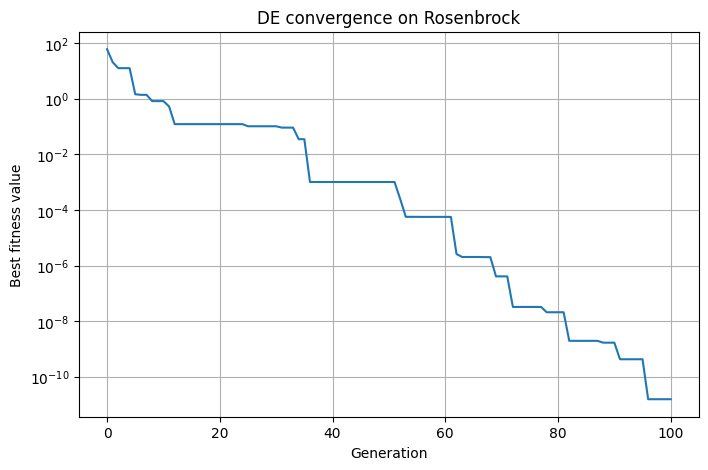

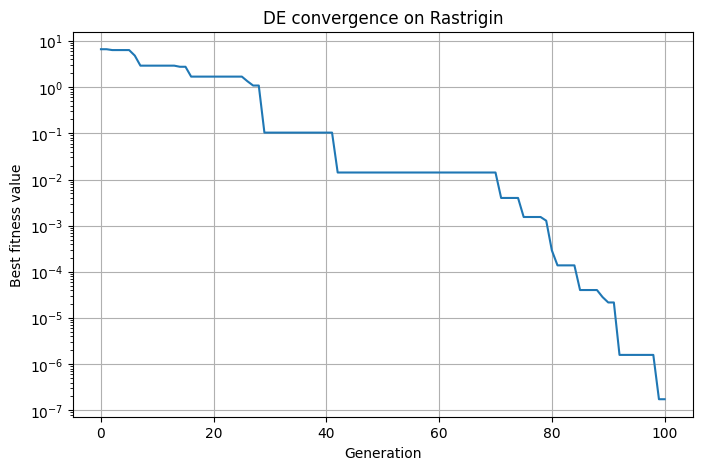

In [10]:
for name, func in experiments.items():
    plot_convergence(
        func=func,
        history=results[name].history,
        title=f"DE convergence on {name}"
    )

In [13]:
for name, func in experiments.items():
    animate_de(
        func=func,
        history=results[name].history,
        bounds=BOUNDS,
        frames=len(results[name].history),
        filename=f"de_{name.lower()}_animation.gif"
    )

Animation saved to de_sphere_animation.gif
Animation saved to de_rosenbrock_animation.gif
Animation saved to de_rastrigin_animation.gif


### Hyperparameters in Differential Evolution

Two hyperparameters drive DE's exploration/exploitation tradeoff:

- **Scaling factor $F$** controls the magnitude of the differential mutation step. Large $F$ → big jumps (exploration); small $F$ → small refinements (exploitation).
- **Crossover rate $CR$** controls how much of the mutant ends up in the trial vector. Large $CR$ → aggressive mixing across coordinates; small $CR$ → trial mostly inherits the target.

#### Task: $F \times CR$ grid search on Rastrigin

Rastrigin is highly multimodal, so it is a good stress test for these knobs. Run a grid over

- $F \in \{0.3,\ 0.5,\ 0.7,\ 0.9\}$
- $CR \in \{0.1,\ 0.3,\ 0.5,\ 0.7,\ 0.9\}$

For each $(F, CR)$ pair, run DE **5 times** with different seeds on **10D Rastrigin** (`bounds = [(-5, 5)] * 10`, `pop_size = 50`, `max_gen = 200`) and record the best final fitness. Aggregate by mean across seeds.

**Deliverables**

1. A heatmap of mean best fitness over the $F \times CR$ grid (e.g. `plt.imshow` with annotated cells, or `seaborn.heatmap`).
2. A short written analysis (3–5 sentences):
   - Which region of the grid performs best, and why?
   - What happens at the extreme corners (low $F$ + low $CR$; high $F$ + high $CR$)?
   - How does the answer connect to the exploration/exploitation framing above?

In [14]:
# 10D Rastrigin setup
rastrigin_10d_bounds = [(-5, 5)] * 10

F_values = [0.3, 0.5, 0.7, 0.9]
CR_values = [0.1, 0.3, 0.5, 0.7, 0.9]
seeds = [0, 1, 2, 3, 4]

mean_best_fitness = np.zeros((len(F_values), len(CR_values)))
all_results = {}

for f_idx, F in enumerate(F_values):
    for cr_idx, CR in enumerate(CR_values):
        final_fitness_values = []

        for seed in seeds:
            result = differential_evolution(
                func=rastrigin,
                bounds=rastrigin_10d_bounds,
                pop_size=50,
                F=F,
                CR=CR,
                max_gen=200,
                seed=seed,
            )

            final_fitness_values.append(result.best_value)

        mean_value = np.mean(final_fitness_values)

        mean_best_fitness[f_idx, cr_idx] = mean_value
        all_results[(F, CR)] = final_fitness_values

        print(
            f"F={F:.1f}, CR={CR:.1f} "
            f"mean best fitness={mean_value:.4f}"
        )

F=0.3, CR=0.1 mean best fitness=0.0681
F=0.3, CR=0.3 mean best fitness=4.6521
F=0.3, CR=0.5 mean best fitness=11.9516
F=0.3, CR=0.7 mean best fitness=15.6506
F=0.3, CR=0.9 mean best fitness=14.2192
F=0.5, CR=0.1 mean best fitness=0.1664
F=0.5, CR=0.3 mean best fitness=8.4061
F=0.5, CR=0.5 mean best fitness=16.0482
F=0.5, CR=0.7 mean best fitness=26.9944
F=0.5, CR=0.9 mean best fitness=34.4421
F=0.7, CR=0.1 mean best fitness=3.9454
F=0.7, CR=0.3 mean best fitness=15.4157
F=0.7, CR=0.5 mean best fitness=20.9216
F=0.7, CR=0.7 mean best fitness=37.5108
F=0.7, CR=0.9 mean best fitness=40.7518
F=0.9, CR=0.1 mean best fitness=0.9316
F=0.9, CR=0.3 mean best fitness=10.2274
F=0.9, CR=0.5 mean best fitness=22.7020
F=0.9, CR=0.7 mean best fitness=44.3252
F=0.9, CR=0.9 mean best fitness=65.5912


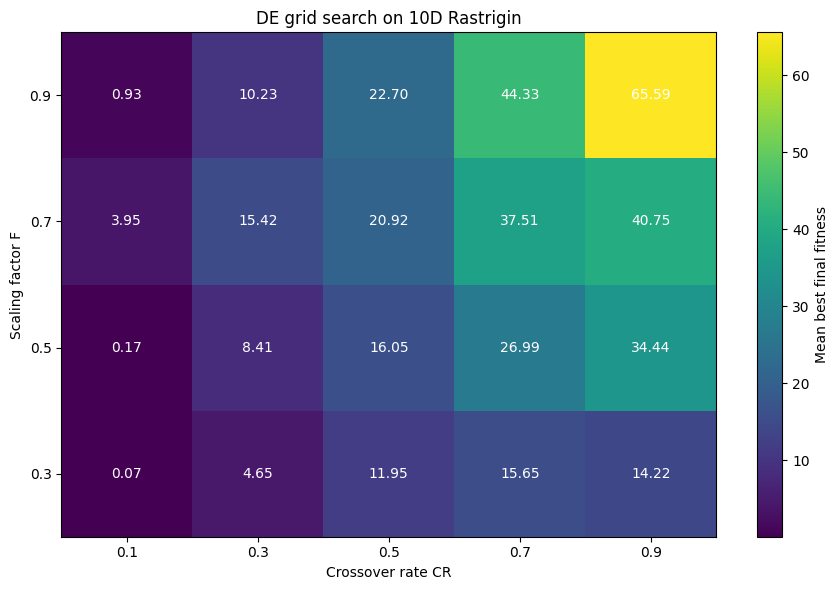

In [17]:
plt.figure(figsize=(9, 6))

im = plt.imshow(
    mean_best_fitness,
    origin="lower",
    aspect="auto"
)

plt.colorbar(im, label="Mean best final fitness")

plt.xticks(
    ticks=np.arange(len(CR_values)),
    labels=CR_values
)

plt.yticks(
    ticks=np.arange(len(F_values)),
    labels=F_values
)

plt.xlabel("Crossover rate CR")
plt.ylabel("Scaling factor F")
plt.title("DE grid search on 10D Rastrigin")

for f_idx in range(len(F_values)):
    for cr_idx in range(len(CR_values)):
        plt.text(
            cr_idx,
            f_idx,
            f"{mean_best_fitness[f_idx, cr_idx]:.2f}",
            ha="center",
            va="center",
            color="white"
        )

plt.tight_layout()
plt.show()

In [18]:
best_index = np.unravel_index(
    np.argmin(mean_best_fitness),
    mean_best_fitness.shape
)

best_F = F_values[best_index[0]]
best_CR = CR_values[best_index[1]]
best_mean = mean_best_fitness[best_index]

print(f"Best setting: F={best_F}, CR={best_CR}")
print(f"Mean best fitness: {best_mean:.4f}")

Best setting: F=0.3, CR=0.1
Mean best fitness: 0.0681


### SHADE: Success-History Based Adaptive Differential Evolution

SHADE is an advanced variant of DE designed to enhance optimization performance through adaptive parameter control. Your task is to critically analyze the research paper [Success-History Based Parameter Adaptation for Differential Evolution](https://metahack.org/CEC2013-SHADE.pdf).
- Summarize the key concepts and mechanisms introduced in SHADE.
- Explain how SHADE differs from the standard DE algorithm.
- Discuss the motivation behind these changes and the empirical improvements demonstrated in the study.

SHADE, czyli **Success-History Based Adaptive Differential Evolution**, jest rozszerzeniem klasycznego algorytmu Differential Evolution, w którym parametry `F` i `CR` nie są ustawiane na stałe. Zamiast tego algorytm przechowuje historię skutecznych wartości tych parametrów w dwóch pamięciach: `M_F` oraz `M_CR`. Na początku wszystkie wpisy w pamięci są ustawione na `0.5`, a w kolejnych generacjach nowe wartości `F_i` i `CR_i` dla poszczególnych osobników są losowane w pobliżu wcześniej skutecznych ustawień. Dzięki temu algorytm uczy się, jakie parametry działały dobrze w danym problemie optymalizacyjnym. Autorzy podkreślają, że skuteczność DE silnie zależy od ustawień `F`, `CR` i rozmiaru populacji, a optymalne wartości są zależne od problemu. :contentReference[oaicite:0]{index=0}

Najważniejszą zmianą względem standardowego DE jest więc adaptacja parametrów. W klasycznym DE `F` i `CR` są zwykle stałe przez cały przebieg algorytmu, natomiast w SHADE są dobierane osobno dla każdego osobnika i każdej generacji. SHADE korzysta również ze strategii mutacji `current-to-pbest/1`, znanej z JADE, w której osobnik jest przesuwany w stronę jednego z najlepszych osobników populacji, ale niekoniecznie zawsze w stronę absolutnie najlepszego. Zmniejsza to ryzyko zbyt szybkiej, zachłannej zbieżności. Dodatkowo wykorzystywane jest archiwum zastąpionych osobników, które pomaga zachować różnorodność populacji. :contentReference[oaicite:1]{index=1}

Mechanizm adaptacji działa na podstawie sukcesów. Jeżeli nowy wektor próbny poprawia wynik względem wektora rodzica, odpowiadające mu wartości `F` i `CR` trafiają do zbiorów skutecznych parametrów. Następnie pamięć historyczna jest aktualizowana za pomocą średnich ważonych, gdzie większą wagę mają te parametry, które doprowadziły do większej poprawy funkcji celu. Dla `F` stosowana jest ważona średnia Lehmera, która mocniej premiuje większe skuteczne wartości `F`. W praktyce oznacza to, że SHADE nie tylko zapamiętuje, co zadziałało, ale też rozróżnia, jak duża była poprawa. :contentReference[oaicite:2]{index=2}

Motywacją dla SHADE była słabość wcześniejszego algorytmu JADE. JADE używa pojedynczych średnich `μ_F` i `μ_CR`, które są aktualizowane na podstawie ostatnich sukcesów. Problem polega na tym, że przez losowy charakter DE nawet słabe ustawienia parametrów mogą czasem przypadkowo dać poprawę, a wtedy pojedyncza średnia może przesunąć się w niekorzystnym kierunku. SHADE ogranicza ten problem, ponieważ przechowuje wiele historycznych ustawień parametrów. Jedna słaba generacja nie niszczy więc całej wiedzy zgromadzonej wcześniej przez algorytm. :contentReference[oaicite:3]{index=3}

Empirycznie autorzy pokazali, że SHADE jest konkurencyjny wobec najlepszych wariantów DE i często je przewyższa. Algorytm testowano między innymi na zestawie benchmarków CEC2013, CEC2005 oraz na 13 klasycznych funkcjach testowych. W porównaniach SHADE osiągał lepsze wyniki od takich metod jak JADE, CoDE, EPSDE i dynNP-jDE. Autorzy zauważyli też, że rozmiar pamięci historycznej `H` ma znaczenie: wartości `H = 30` i `H = 50` były nieco lepsze niż `H = 100`, natomiast zbyt duża pamięć pogarszała wyniki, bo stare informacje zbyt długo wpływały na nowe parametry. :contentReference[oaicite:4]{index=4} :contentReference[oaicite:5]{index=5}

Podsumowując, SHADE zachowuje główną strukturę Differential Evolution: populację, mutację, krzyżowanie i selekcję. Różnica polega na tym, że algorytm sam adaptuje parametry sterujące na podstawie historii sukcesów. Dzięki temu lepiej równoważy eksplorację i eksploatację: większe wartości `F` mogą pomagać w przeskakiwaniu między obszarami poszukiwań, a mniejsze wartości oraz odpowiednio dobrane `CR` wspierają dokładniejsze dopracowanie rozwiązania. SHADE nie usuwa całkowicie potrzeby ustawiania hiperparametrów, ponieważ nadal trzeba dobrać między innymi rozmiar populacji i rozmiar pamięci `H`, ale znacząco zmniejsza zależność algorytmu od ręcznie dobranych wartości `F` i `CR`.

### Recommended Reading
1. https://pablormier.github.io/2017/09/05/a-tutorial-on-differential-evolution-with-python/
2. Das, Swagatam, and Ponnuthurai Nagaratnam Suganthan. [Differential evolution: A survey of the state-of-the-art.](https://i2pc.es/coss/Docencia/SignalProcessingReviews/Das2011.pdf)
3. Tanabe, Ryoji, and Alex Fukunaga. [Success-history based parameter adaptation for differential evolution.](https://metahack.org/CEC2013-SHADE.pdf)